In [1]:
import torch
import pandas
import torchvision
import os
from torch.utils.data import Dataset,DataLoader
import scipy.io as scio
# Hyper parameters
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  # 添加这一行引入torch.nn.functional模块
import copy
import numpy as np
import matplotlib
import time
import h5py
from matplotlib import animation
from sklearn.metrics import confusion_matrix
from matplotlib.animation import FuncAnimation
from matplotlib import pyplot as plt
import hiddenlayer as hl
import pywt
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
class MyDataset(Dataset):
    def __init__(self,root,sets):
       f = h5py.File(root ,'r')
       if sets == 'train':
           self.X = f['X_train'][:]
           self.y = f['y_train'][:]
       elif sets == 'val':
           self.X = f['X_val'][:]
           self.y = f['y_val'][:]
       else:
           self.X = f['X_test'][:]
           self.y = f['y_test'][:] 
    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
#混合降噪模块

class HybridDenoising(nn.Module):
    def __init__(self, channels=1, wavelet='db4', level=3, learnable_threshold=True):
        """
        混合降噪模块：结合卷积噪声抑制与小波降噪
        参数:
            channels: 输入通道数，默认1
            wavelet: 使用的小波基，默认'db4'
            level: 小波分解层数，默认3
            learnable_threshold: 是否让阈值可学习，默认True
        """
        super(HybridDenoising, self).__init__()
        self.channels = channels
        self.wavelet = wavelet
        self.level = level
        
        # 可学习的卷积噪声抑制层
        self.conv_suppress = nn.Sequential(
            nn.Conv2d(channels, 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(inplace=True),
            nn.Conv2d(4, channels, kernel_size=1, bias=False),
            nn.Sigmoid()  # 生成噪声抑制掩码
        )
        
        # 可学习的阈值因子
        self.threshold_factor = nn.Parameter(torch.tensor(1.0), requires_grad=learnable_threshold)
        self.learnable_threshold = learnable_threshold
        
        # 小波系数重要性估计网络
        self.wavelet_importance = nn.Sequential(
            nn.Linear(self.level + 1, 32),
            nn.ReLU(),
            nn.Linear(32, self.level + 1),
            nn.Sigmoid()
        )
    
    def wavelet_denoise(self, signal):
        """应用小波降噪到单个信号"""
        # 小波分解
        coeffs = pywt.wavedec(signal, self.wavelet, level=self.level)
        
        # 估计噪声水平
        if len(coeffs[-1]) > 0:
            sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        else:
            sigma = 1.0  # 避免除以零
        
        # 计算自适应阈值
        threshold = self.threshold_factor.item() * sigma * np.sqrt(2 * np.log(len(signal)))
        
        # 应用阈值处理（保留近似系数）
        thresholded_coeffs = [coeffs[0]]  # 近似系数保持不变
        for i in range(1, len(coeffs)):
            thresholded_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
        
        # 小波重构
        denoised_signal = pywt.waverec(thresholded_coeffs, self.wavelet)
        
        # 确保长度匹配
        if len(denoised_signal) > len(signal):
            denoised_signal = denoised_signal[:len(signal)]
        elif len(denoised_signal) < len(signal):
            denoised_signal = np.pad(denoised_signal, (0, len(signal) - len(denoised_signal)), 'constant')
        
        return denoised_signal
    
    def forward(self, x):
        # 第一步：卷积噪声抑制
        conv_mask = self.conv_suppress(x)
        conv_denoised = x * conv_mask
        
        # 第二步：小波降噪（在CPU上执行）
        device = x.device
        x_np = conv_denoised.detach().cpu().numpy()
        
        # 处理批处理维度
        batch_size, channels, height, width = x_np.shape
        denoised_signals = np.zeros_like(x_np)
        
        # 对每个样本和通道应用小波降噪
        for b in range(batch_size):
            for c in range(channels):
                signal = x_np[b, c, :, 0].squeeze()
                denoised_signals[b, c, :, 0] = self.wavelet_denoise(signal)
        
        # 转回PyTorch张量
        wave_denoised = torch.tensor(denoised_signals, dtype=x.dtype).to(device)
        
        # 自适应融合：使用卷积层学习融合权重
        # 修复此处缺少右括号的问题
        fusion_weights = torch.sigmoid(
            torch.mean(conv_mask, dim=[2, 3], keepdim=True))
        
        # 融合结果：在训练阶段保持梯度流
        denoised = fusion_weights * wave_denoised + (1 - fusion_weights) * conv_denoised
        
        # 梯度重定向：确保梯度可以回传到卷积部分
        denoised = denoised + (conv_denoised - conv_denoised.detach())
        
        return denoised

In [4]:
Epoch = 300
Batch_Size = 200
Learning_Rate = 0.001

In [5]:
data_path = 'DataBase_12K_HP_0.h5'
train_dataset = MyDataset(data_path, 'train')
val_dataset = MyDataset(data_path, 'val')

# 查看训练集的结构
for i in range(len(train_dataset)):
    input_data, label_data = train_dataset[i]
    print("Train Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息

# 查看验证集的结构
for i in range(len(val_dataset)):
    input_data, label_data = val_dataset[i]
    print("Validation Sample ", i)
    print("Input Shape:", input_data.shape)
    print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
    
train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Batch_Size, shuffle=True)
# Checking the dataset
for dataset, labels in train_loader:
    print('Signals batch dimensions:', dataset.shape)#四维张量可以被理解为包含200个样本，每个样本有1个通道，
                                                     #每个通道包含1024个元素，每个元素的深度为1
    print('Signals label dimensions:', labels.shape)
    break
print('#training num = %d' % len(train_dataset))
print('#val num = %d' % len(val_dataset))

Train Sample  0
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  1
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  2
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  3
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  4
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  5
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  6
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  7
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  8
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  9
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  10
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  11
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  12
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  13
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  14
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  15
Input Shape: (1, 1024, 1)
Label Shape: ()
Train Sample  16
Input Shape: (1, 1024, 1)
Label Shape: ()
Train S

In [6]:
class CNN_LSTM_Attention(nn.Module):
    def __init__(self):
        super(CNN_LSTM_Attention, self).__init__()
        # 添加混合降噪模块
        self.hybrid_denoise = HybridDenoising(channels=1)
        
        # 保持原有CNN结构
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=[16, 1], stride=[7, 1], padding=0, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=[7, 1], stride=[4, 1], padding=0, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=[3, 1], stride=[2, 1], padding=0, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.lstm = nn.LSTM(input_size=17, hidden_size=64, num_layers=2, bias=False, batch_first=True)
        self.attention = nn.MultiheadAttention(embed_dim=64, num_heads=1)
        self.fully_connect = nn.Linear(64, 11)
        self.classifier = nn.Softmax(dim=1)

    def forward(self, x):
        # 首先通过混合降噪层
        x = self.hybrid_denoise(x)
        
        # 保持原有前向传播
        residual = x
        x = self.cnn(x)
        residual = F.interpolate(residual, size=x.size()[2:], mode='nearest')
        x = x + residual
        
        y, _ = self.lstm(x.squeeze(3))
        attention_output, _ = self.attention(y, y, y)
        logits = self.fully_connect(attention_output[:, -1, :])
        probs = self.classifier(logits)
        return logits, probs

In [7]:
# 实例化模型
model = CNN_LSTM_Attention()

In [8]:
# 定义优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_Rate)
loss_func = nn.CrossEntropyLoss()

epoch 0
Training Accuracy is  0.065
Training Accuracy is  0.080
Training Accuracy is  0.080
Training Accuracy is  0.115
Training Accuracy is  0.075
Training Accuracy is  0.095
Training Accuracy is  0.065
Training Accuracy is  0.090
Training Accuracy is  0.085
Training Accuracy is  0.085
Training Accuracy is  0.075
epoch 1
Training Accuracy is  0.085
Training Accuracy is  0.080
Training Accuracy is  0.120
Training Accuracy is  0.095
Training Accuracy is  0.060
Training Accuracy is  0.110
Training Accuracy is  0.095
Training Accuracy is  0.080
Training Accuracy is  0.105
Validation Accuracy is  0.095
Validation Accuracy is  0.135
Validation Accuracy is  0.095
Validation Accuracy is  0.105
Validation Accuracy is  0.045
Validation Accuracy is  0.055
Validation Accuracy is  0.110
Validation Accuracy is  0.105
Validation Accuracy is  0.080
Validation Accuracy is  0.080
Validation Accuracy is  0.095
Training Accuracy is  0.115
Training Accuracy is  0.055
epoch 2
Training Accuracy is  0.130
Tr

Training Accuracy is  0.120
Training Accuracy is  0.065
Training Accuracy is  0.060
Training Accuracy is  0.070
Training Accuracy is  0.070
epoch 17
Training Accuracy is  0.090
Training Accuracy is  0.080
Training Accuracy is  0.075
Training Accuracy is  0.125
Training Accuracy is  0.060
Training Accuracy is  0.105
Training Accuracy is  0.085
Training Accuracy is  0.095
Training Accuracy is  0.115
Training Accuracy is  0.060
Training Accuracy is  0.095
epoch 18
Training Accuracy is  0.110
Training Accuracy is  0.070
Validation Accuracy is  0.080
Validation Accuracy is  0.090
Validation Accuracy is  0.105
Validation Accuracy is  0.085
Validation Accuracy is  0.090
Validation Accuracy is  0.070
Validation Accuracy is  0.080
Validation Accuracy is  0.075
Validation Accuracy is  0.090
Validation Accuracy is  0.115
Validation Accuracy is  0.120
Training Accuracy is  0.085
Training Accuracy is  0.100
Training Accuracy is  0.030
Training Accuracy is  0.090
Training Accuracy is  0.070
Training

Training Accuracy is  0.200
Training Accuracy is  0.150
Training Accuracy is  0.125
Training Accuracy is  0.215
Training Accuracy is  0.175
Training Accuracy is  0.170
Training Accuracy is  0.195
Training Accuracy is  0.140
Training Accuracy is  0.145
Training Accuracy is  0.150
epoch 34
Training Accuracy is  0.135
Training Accuracy is  0.170
Training Accuracy is  0.170
Training Accuracy is  0.180
Training Accuracy is  0.195
Training Accuracy is  0.210
Validation Accuracy is  0.200
Validation Accuracy is  0.165
Validation Accuracy is  0.170
Validation Accuracy is  0.230
Validation Accuracy is  0.220
Validation Accuracy is  0.200
Validation Accuracy is  0.155
Validation Accuracy is  0.190
Validation Accuracy is  0.175
Validation Accuracy is  0.190
Validation Accuracy is  0.165
Training Accuracy is  0.130
Training Accuracy is  0.155
Training Accuracy is  0.190
Training Accuracy is  0.195
Training Accuracy is  0.180
epoch 35
Training Accuracy is  0.150
Training Accuracy is  0.215
Training

Training Accuracy is  0.250
Training Accuracy is  0.325
Training Accuracy is  0.325
Training Accuracy is  0.320
epoch 50
Training Accuracy is  0.330
Training Accuracy is  0.260
Training Accuracy is  0.315
Training Accuracy is  0.330
Training Accuracy is  0.215
Training Accuracy is  0.300
Training Accuracy is  0.365
Training Accuracy is  0.330
Training Accuracy is  0.365
Training Accuracy is  0.385
Validation Accuracy is  0.390
Validation Accuracy is  0.375
Validation Accuracy is  0.290
Validation Accuracy is  0.340
Validation Accuracy is  0.260
Validation Accuracy is  0.380
Validation Accuracy is  0.365
Validation Accuracy is  0.325
Validation Accuracy is  0.320
Validation Accuracy is  0.305
Validation Accuracy is  0.305
Training Accuracy is  0.370
epoch 51
Training Accuracy is  0.320
Training Accuracy is  0.355
Training Accuracy is  0.405
Training Accuracy is  0.285
Training Accuracy is  0.355
Training Accuracy is  0.310
Training Accuracy is  0.265
Training Accuracy is  0.355
Training

Training Accuracy is  0.485
Training Accuracy is  0.465
Training Accuracy is  0.540
Training Accuracy is  0.385
Training Accuracy is  0.400
Training Accuracy is  0.400
Training Accuracy is  0.500
Training Accuracy is  0.415
Training Accuracy is  0.375
epoch 67
Training Accuracy is  0.425
Training Accuracy is  0.400
Training Accuracy is  0.515
Validation Accuracy is  0.490
Validation Accuracy is  0.490
Validation Accuracy is  0.445
Validation Accuracy is  0.385
Validation Accuracy is  0.425
Validation Accuracy is  0.390
Validation Accuracy is  0.475
Validation Accuracy is  0.375
Validation Accuracy is  0.395
Validation Accuracy is  0.330
Validation Accuracy is  0.425
Training Accuracy is  0.365
Training Accuracy is  0.345
Training Accuracy is  0.415
Training Accuracy is  0.540
Training Accuracy is  0.445
Training Accuracy is  0.365
Training Accuracy is  0.395
Training Accuracy is  0.410
epoch 68
Training Accuracy is  0.490
Training Accuracy is  0.500
Training Accuracy is  0.465
Training

...

Validation Accuracy is  0.870
Validation Accuracy is  0.840
Validation Accuracy is  0.895
Validation Accuracy is  0.880
Validation Accuracy is  0.895
Validation Accuracy is  0.890
Validation Accuracy is  0.820
Validation Accuracy is  0.880
Validation Accuracy is  0.865
Validation Accuracy is  0.870
Validation Accuracy is  0.925
Training Accuracy is  0.905
epoch 231
Training Accuracy is  0.905
Training Accuracy is  0.880
Training Accuracy is  0.945
Training Accuracy is  0.905
Training Accuracy is  0.880
Training Accuracy is  0.930
Training Accuracy is  0.930
Training Accuracy is  0.865
Training Accuracy is  0.925
Training Accuracy is  0.880
Training Accuracy is  0.900
epoch 232
Training Accuracy is  0.940
Training Accuracy is  0.910
Training Accuracy is  0.925
Training Accuracy is  0.935
Training Accuracy is  0.880
Training Accuracy is  0.930
Training Accuracy is  0.910
Training Accuracy is  0.930
Validation Accuracy is  0.910
Validation Accuracy is  0.885
Validation Accuracy is  0.905


Validation Accuracy is  0.915
Validation Accuracy is  0.875
Validation Accuracy is  0.875
Validation Accuracy is  0.860
Validation Accuracy is  0.960
Validation Accuracy is  0.965
Validation Accuracy is  0.890
Validation Accuracy is  0.845
Validation Accuracy is  0.880
Validation Accuracy is  0.885
Training Accuracy is  1.000
Training Accuracy is  0.960
Training Accuracy is  0.865
Training Accuracy is  0.860
Training Accuracy is  0.930
Training Accuracy is  0.905
Training Accuracy is  0.900
Training Accuracy is  0.980
epoch 248
Training Accuracy is  0.840
Training Accuracy is  1.000
Training Accuracy is  0.955
Training Accuracy is  0.885
Training Accuracy is  0.835
Training Accuracy is  0.940
Training Accuracy is  0.980
Training Accuracy is  0.945
Training Accuracy is  0.955
Training Accuracy is  0.975
Training Accuracy is  0.980
epoch 249
Training Accuracy is  0.985
Validation Accuracy is  0.950
Validation Accuracy is  0.975
Validation Accuracy is  0.955
Validation Accuracy is  0.955


Validation Accuracy is  0.960
Validation Accuracy is  0.965
Validation Accuracy is  0.875
Validation Accuracy is  0.955
Validation Accuracy is  0.980
Validation Accuracy is  0.920
Validation Accuracy is  0.935
Validation Accuracy is  0.975
Validation Accuracy is  0.900
Training Accuracy is  0.965
Training Accuracy is  0.985
Training Accuracy is  0.900
Training Accuracy is  0.950
epoch 264
Training Accuracy is  0.965
Training Accuracy is  1.000
Training Accuracy is  0.985
Training Accuracy is  0.960
Training Accuracy is  0.940
Training Accuracy is  0.900
Training Accuracy is  0.900
Training Accuracy is  0.925
Training Accuracy is  0.990
Training Accuracy is  0.990
Training Accuracy is  0.985
epoch 265
Training Accuracy is  0.905
Training Accuracy is  1.000
Training Accuracy is  0.990
Training Accuracy is  0.990
Training Accuracy is  0.985
Validation Accuracy is  0.970
Validation Accuracy is  0.975
Validation Accuracy is  0.850
Validation Accuracy is  0.965
Validation Accuracy is  0.970


Validation Accuracy is  0.930
Validation Accuracy is  0.955
Validation Accuracy is  0.970
Validation Accuracy is  0.970
Validation Accuracy is  0.990
Validation Accuracy is  0.980
Validation Accuracy is  0.975
Validation Accuracy is  0.975
epoch 280
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.995
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.950
epoch 281
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.985
Training Accuracy is  0.995
Training Accuracy is  0.995
Training Accuracy is  1.000
Training Accuracy is  0.995
Validation Accuracy is  0.965
Validation Accuracy is  0.975
Validation Accuracy is  0.975
Validation Accuracy is  0.980
Validation Accuracy is  0.955
Validation Accuracy is  0.970


Validation Accuracy is  0.995
Validation Accuracy is  0.975
Validation Accuracy is  0.960
Validation Accuracy is  0.965
Validation Accuracy is  0.975
Validation Accuracy is  0.980
Validation Accuracy is  0.995
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  0.995
Training Accuracy is  1.000
Training Accuracy is  1.000
epoch 297
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
Training Accuracy is  1.000
epoch 298
Training Accuracy is  1.000
Training Accuracy is  0.990
Validation Accuracy is  0.990
Validation Accuracy is  0.995
Validation Accuracy is  0.980
Validation Accuracy is  0.965
Validation Accuracy is  0.985
Validation Accuracy is  0.970
Validation Accuracy is  0.975


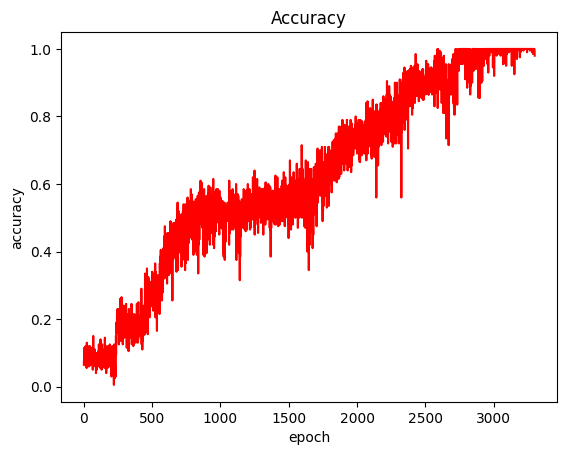

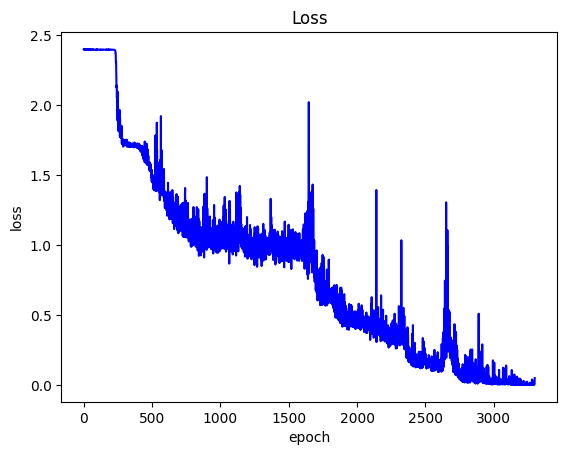

In [9]:
use_cuda = torch.cuda.is_available()
if use_cuda:
    print('CUDA is available')
device = torch.device('cuda:0' if use_cuda else "cpu")
# device = torch.device("cpu")
model = model.to(device)
# save best_model wrt. val_acc
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
Best_Acc = 0.0
loss_list = []
acc_list =[]
val_acc_list = []
val_loss_list = []
global_step = []

history = hl.History()
canvas = hl.Canvas()

for epoch in range(Epoch):
    print ("epoch", epoch)
    for step, (XTrain, YTrain) in enumerate(train_loader):
        num_correct = 0
        model.train()
        XTrain, YTrain = XTrain.float(), YTrain.long()
        XTrain, YTrain = XTrain.to(device), YTrain.to(device)
        logits, probas = model(XTrain)
        loss = loss_func(logits, YTrain)
        preds = probas.max(1, keepdim=True)[1]
        acc = preds.eq(YTrain.view_as(preds)).sum().item() / len(YTrain)
        print("Training Accuracy is %6.3f" % acc)
        loss_list.append(loss)
        acc_list.append(acc)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        global_step.append(epoch * len(train_loader) + step + 1)

        if len(global_step) % 20 == 0:
            model.eval()
            with torch.no_grad():
                for XValidation, YValidation in val_loader:
                    XValidation, YValidation = XValidation.float(), YValidation.long()
                    XValidation, YValidation = XValidation.to(device), YValidation.to(device)
                    val_logits, val_probas = model(XValidation)
                    val_loss = loss_func(val_logits, YValidation)
                    val_loss_list.append(val_loss)
                    val_preds = val_probas.max(1, keepdim=True)[1]
                    val_acc = val_preds.eq(YValidation.view_as(val_preds)).sum().item() / len(YValidation)
                    print("Validation Accuracy is %6.3f" % val_acc)
                    val_acc_list.append(val_acc)
                    if val_acc > best_acc:
                        best_acc = val_acc
                        best_model_wts = copy.deepcopy(model.state_dict())

# 存储最佳验证的模型
torch.save(best_model_wts, 'Dnn_wave_model.pkl')
#绘图
plt.figure(1)
plt.plot(global_step ,acc_list,'r-')
plt.title('Accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.savefig('Dnn_wave_acc.jpg')
plt.show()

#plt.clf()
plt.figure(2)
loss_list = [loss.cpu().detach().numpy() for loss in loss_list]  
plt.plot(global_step, loss_list, 'b-')
plt.title('Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.savefig('Dnn_wave_loss.jpg')
plt.show()

#test num = 2200
Average Test Accuracy: 98.1136%


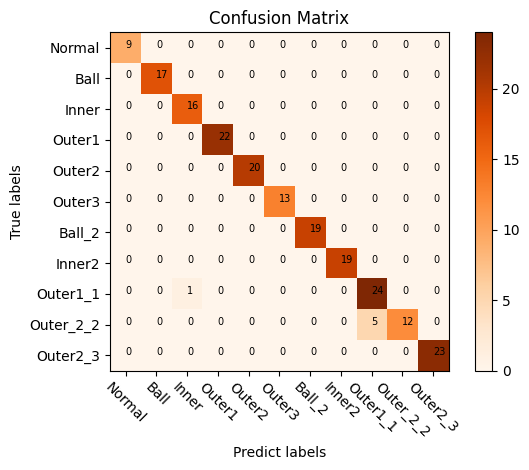

Correct_samples: 194
Total_samples: 200
Test Accuracy: 97.0000%


In [10]:
BATCH_SIZE=200 
test_acc_mean = [] 
test_dataset = MyDataset(data_path,'test')

# 查看测试集的结构
for i in range(len(test_dataset)):
    input_data, label_data = test_dataset[i]
    #print("Test Sample ", i)
    #print("Input Shape:", input_data.shape)
    #print("Label Shape:", label_data.shape)
    # 可以根据实际情况打印更多信息
    
print('#test num = %d' % len(test_dataset))
    
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)

def restore_params(): # load the params of the net 
    models = CNN_LSTM_Attention()
    models.load_state_dict(torch.load('Dnn_wave_model.pkl'))
    return models

test_acc_list = []
con_matrix = np.zeros([11, 11])
for i in range(10):
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)   # BATCH_SIZE,1,1024,1
    mymodel = restore_params()
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        print('CUDA is available') 
    device = torch.device("cuda" if use_cuda else "cpu")
    mymodel = mymodel.to(device)
    for XTest, YTest in test_loader:
        XTest, YTest = XTest.float(), YTest.long()
        XTest, YTest = XTest.to(device), YTest.to(device)
        test_logits, test_probas = mymodel(XTest)
        test_preds = test_probas.max(1, keepdim=True)[1]
        test_acc = test_preds.eq(YTest.view_as(test_preds)).sum().item() / len(YTest)
        #cm = confusion_matrix(YTest, test_preds)
        cm = confusion_matrix(YTest.cpu(), test_preds.cpu())
        con_matrix += cm
        test_acc_list.append(test_acc)
        
# 计算平均测试准确率
average_test_acc = sum(test_acc_list) / len(test_acc_list)
print("Average Test Accuracy: {:.4f}%".format(average_test_acc * 100))

# visualization the Network
from matplotlib import pyplot as plt
classes = ['Normal','Ball','Inner','Outer1','Outer2','Outer3','Ball_2','Inner2', 'Outer1_1', 'Outer_2_2', 'Outer2_3']
yourconfusion = np.array(cm)
plt.imshow(yourconfusion, interpolation='nearest', cmap=plt.cm.Oranges)  #按照像素显示出矩阵
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=-45)
plt.yticks(tick_marks, classes)
thresh = yourconfusion.max() / 2.
iters = [[i,j] for i in range(len(classes)) for j in range((len(classes)))]
for i, j in iters:
    plt.text(j, i, format(yourconfusion [i, j]), fontsize=7)

plt.ylabel('True labels')
plt.xlabel('Predict labels')
plt.tight_layout()
plt.savefig('Bace_wave_confusion_matrix.jpg')
plt.show()

# 根据混淆矩阵计算测试精度
true_positives = yourconfusion.diagonal().sum()
print("Correct_samples: {}".format(true_positives))
total_samples = yourconfusion.sum()
print("Total_samples: {}".format(total_samples))
test_accuracy = true_positives / total_samples
print("Test Accuracy: {:.4f}%".format(test_accuracy * 100))